In [1]:
from pathlib import Path

import numpy as np
from numpy.random import SeedSequence, default_rng

from olbootstrap.experiments._experiments import OnlineARBootstrapExperiment
from olbootstrap.plotting._plotting import BootstrapPlotter
from olbootstrap.synthetic_time_series._ar1 import AR1Process
from olbootstrap.synthetic_time_series._garch import GARCH11Process

/opt/anaconda3/envs/bootstrap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sine-GARCH(1,1) | Uniform covered: True | fraction covered: 1.000 | last q_active≈3.7011726950273665


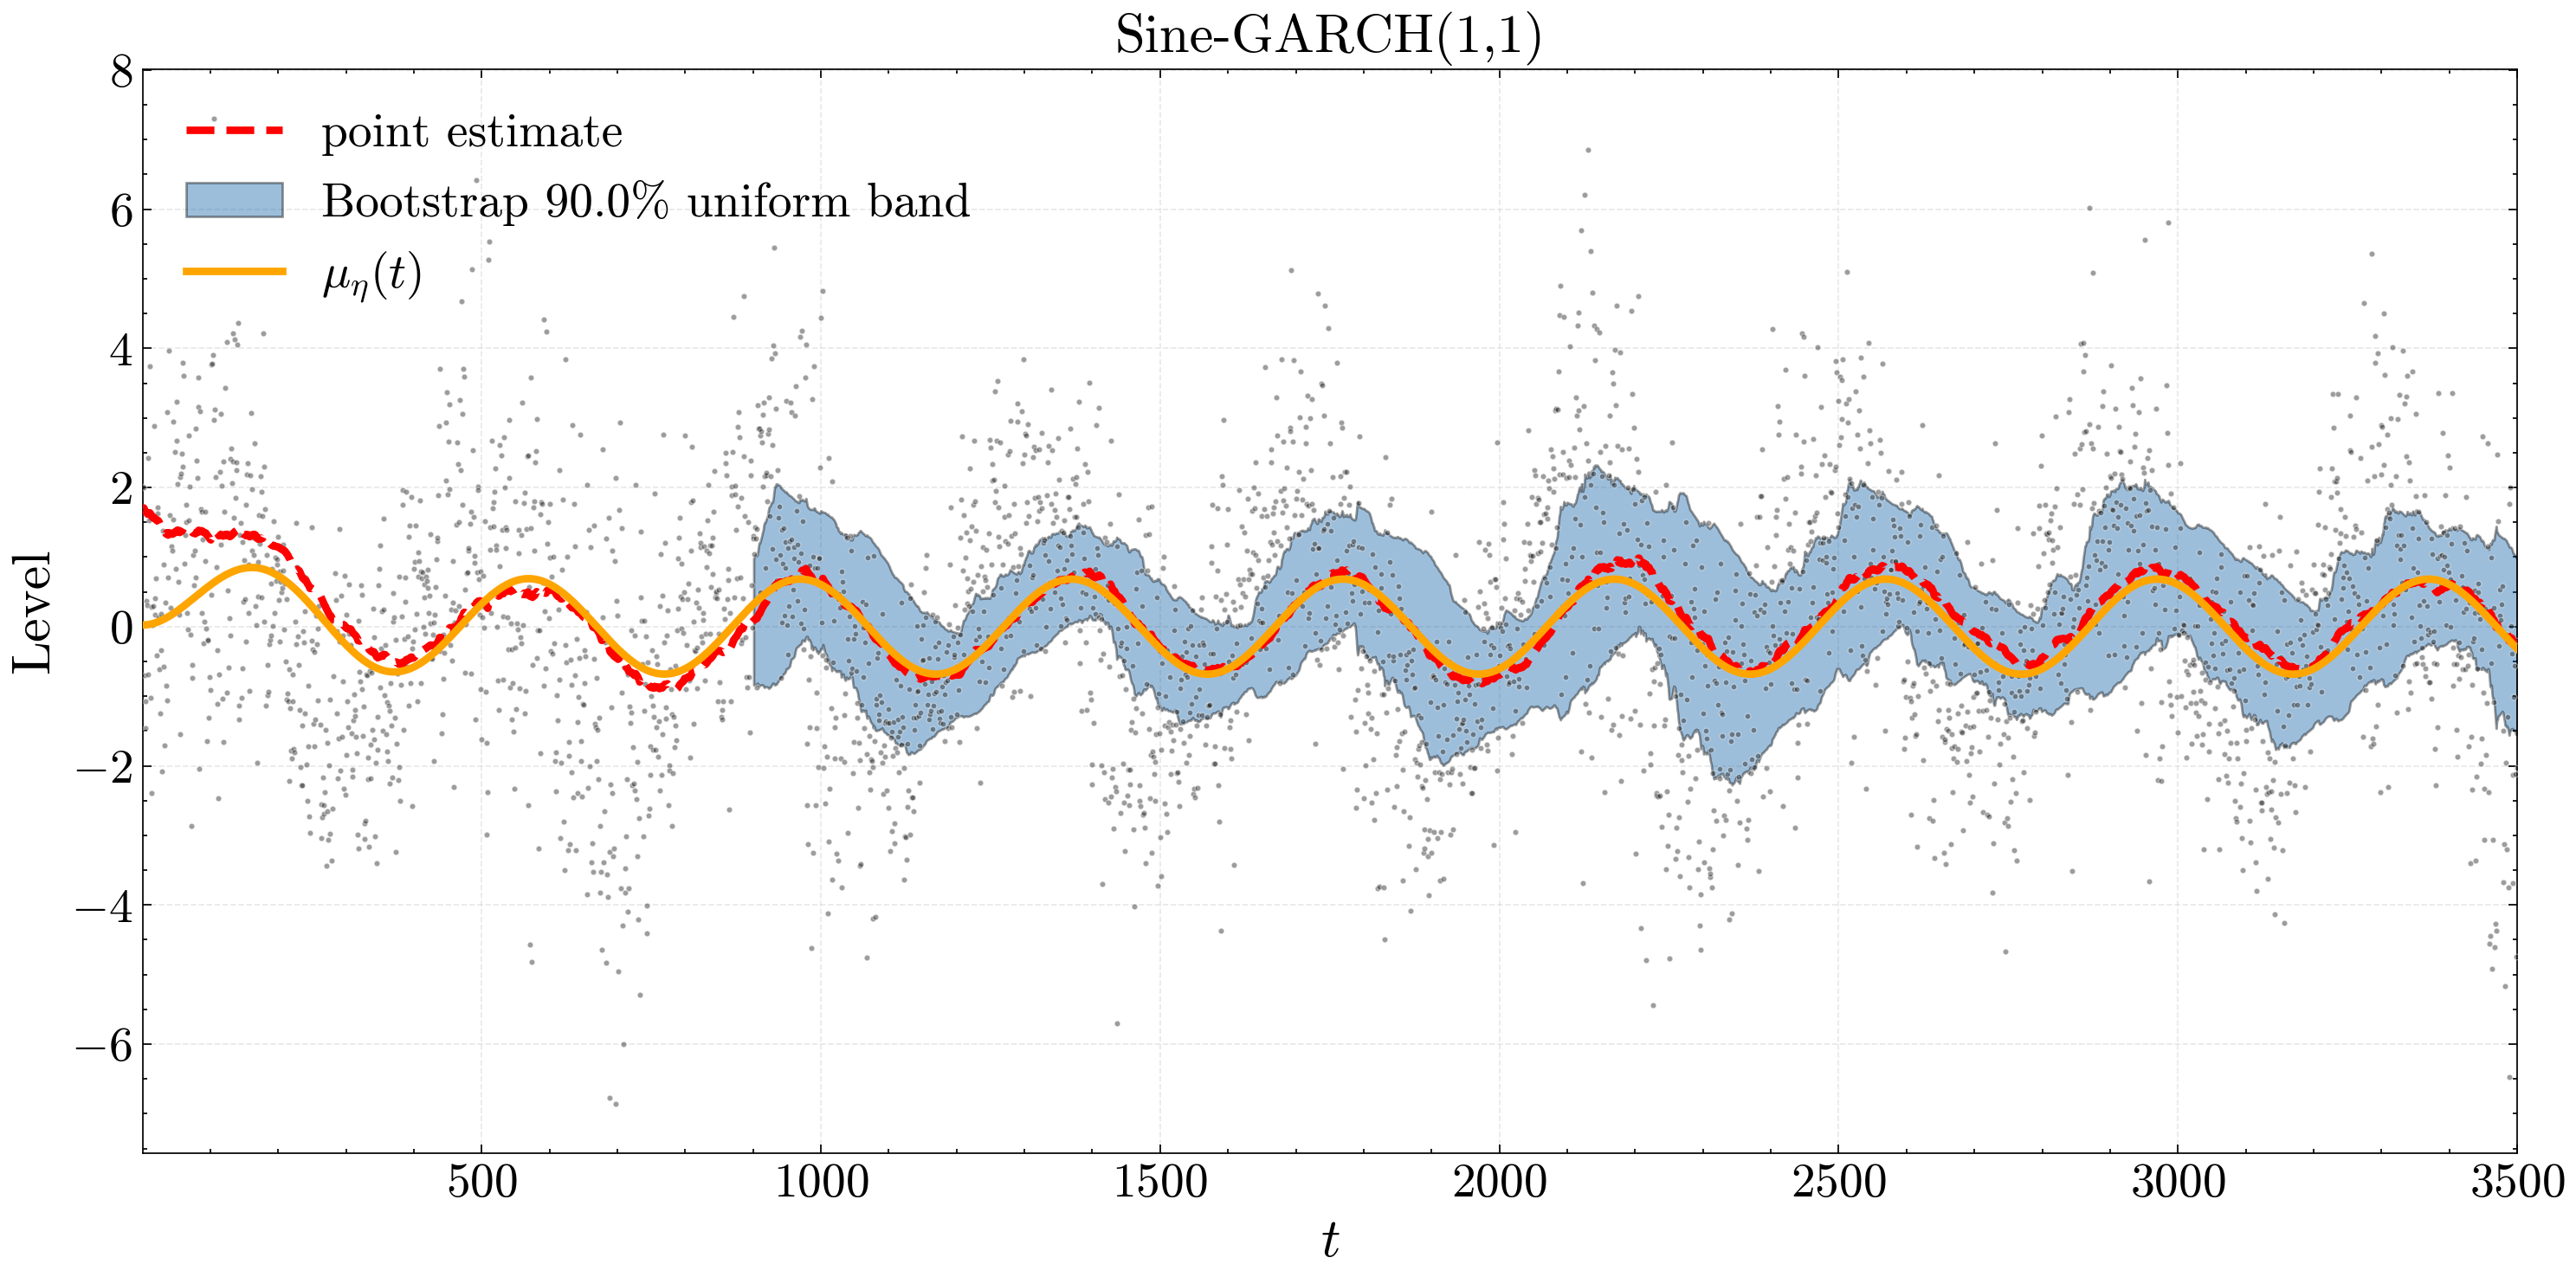

Sparse AR(20) | Uniform covered: True | fraction covered: 1.000 | last q_active≈4.396042152070774


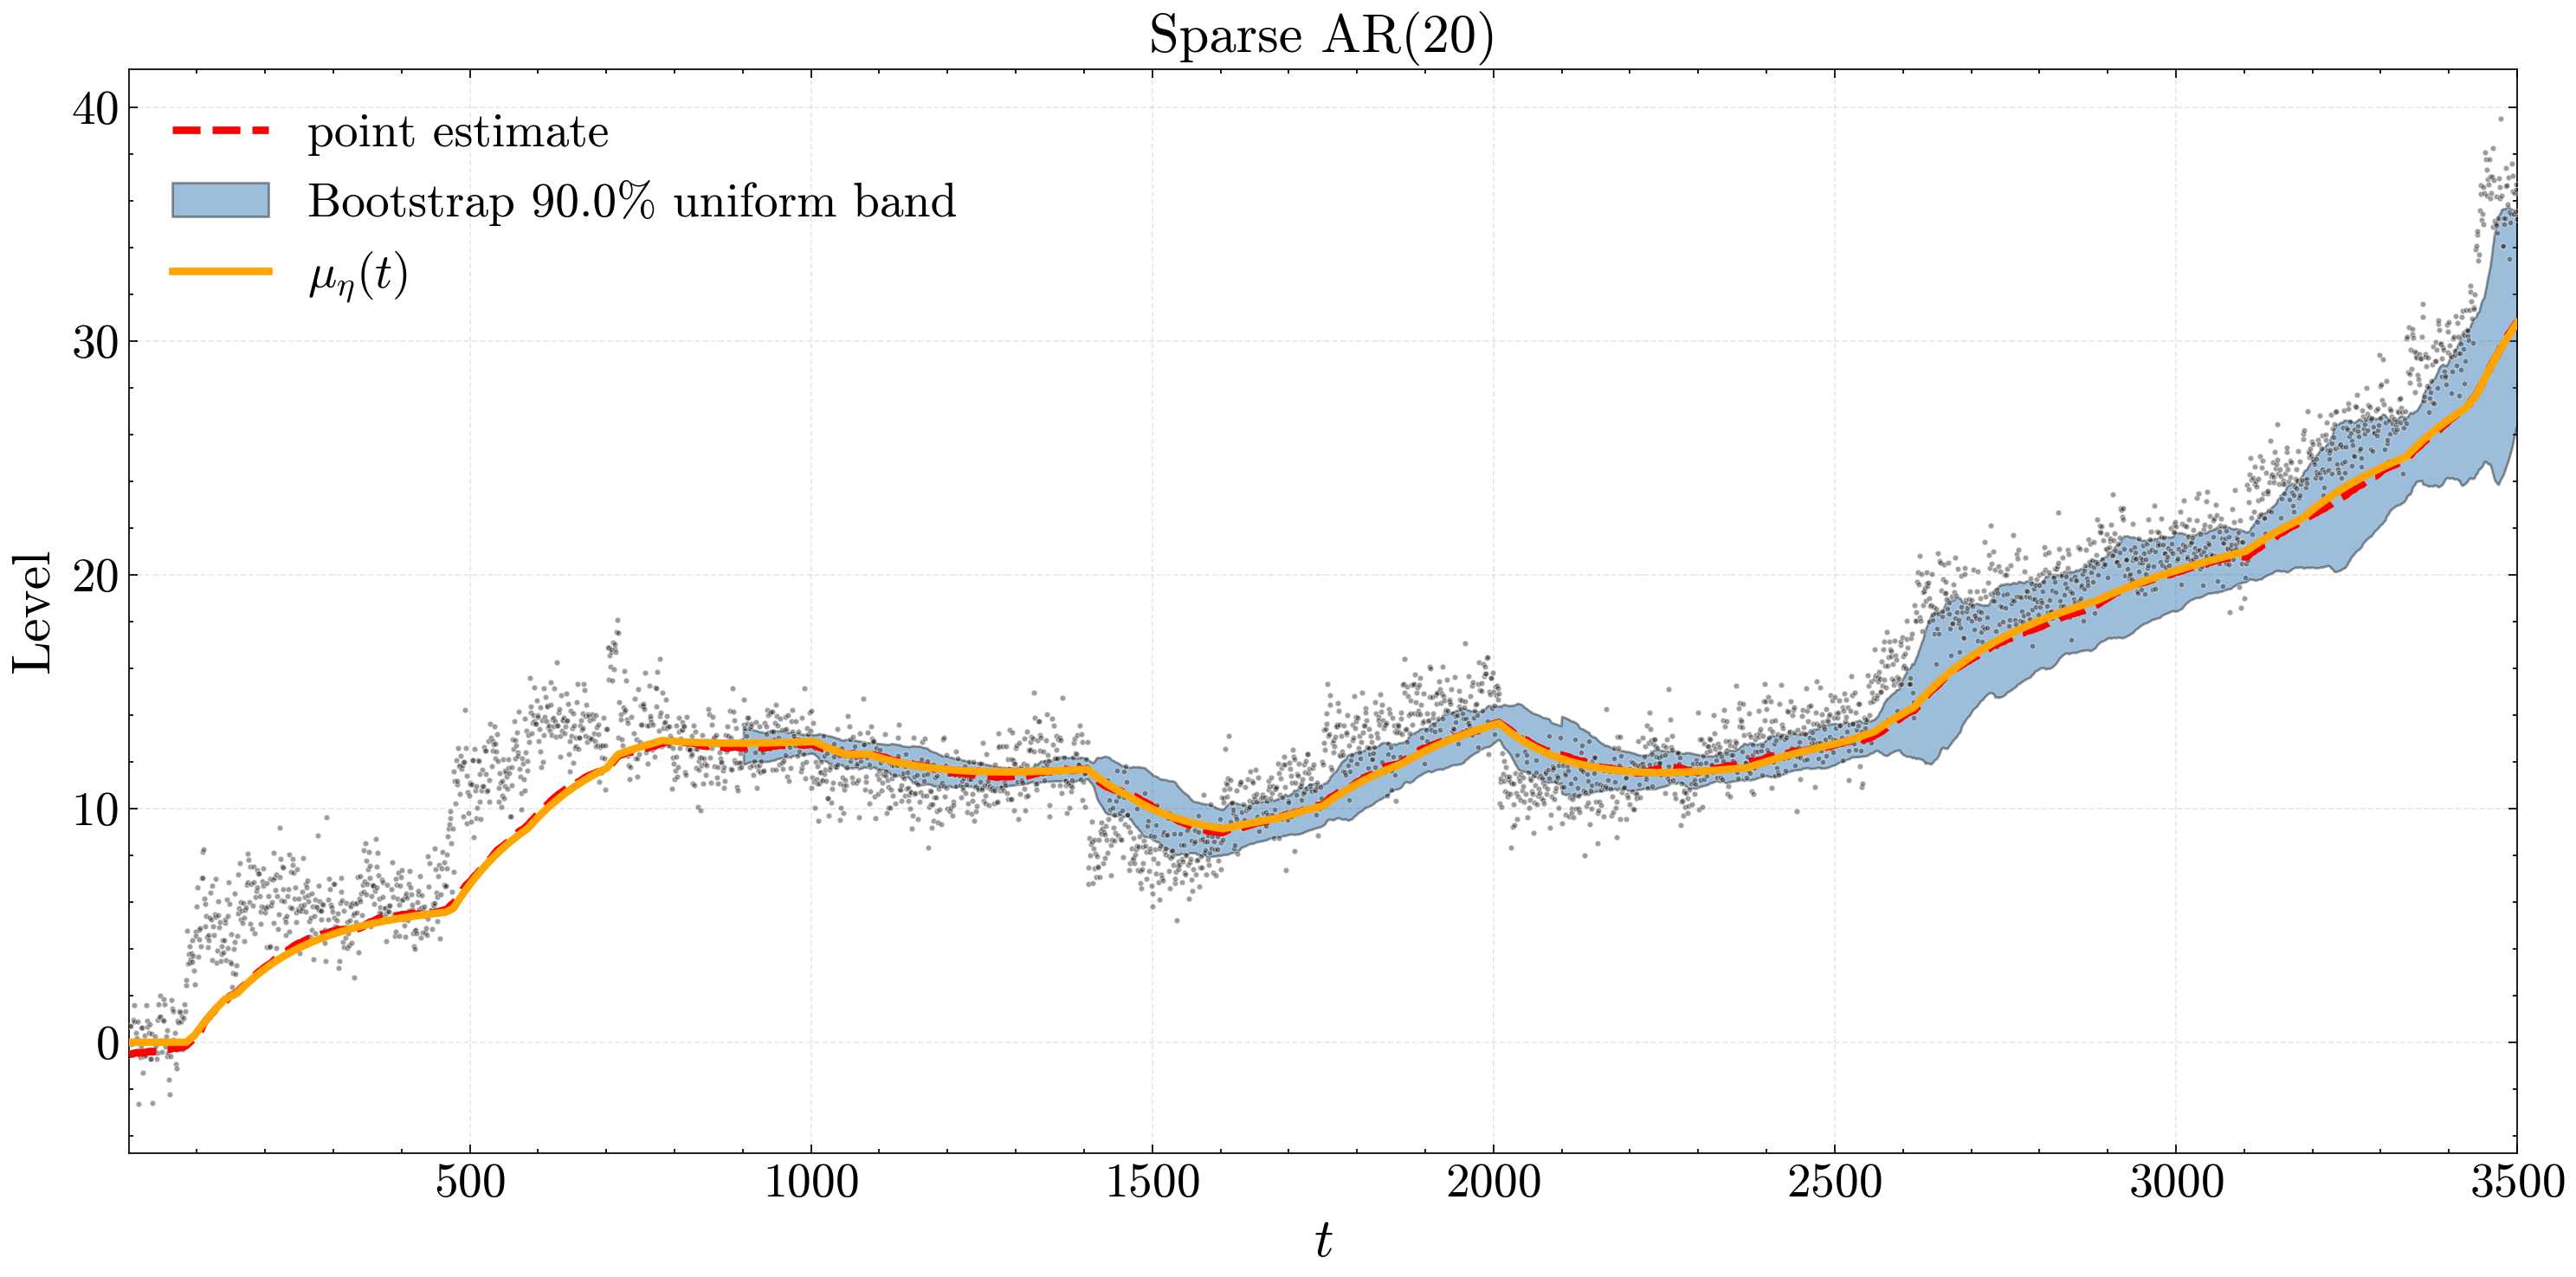

Structural break with trend reversal | Uniform covered: False | fraction covered: 0.988 | last q_active≈4.6983627384192586


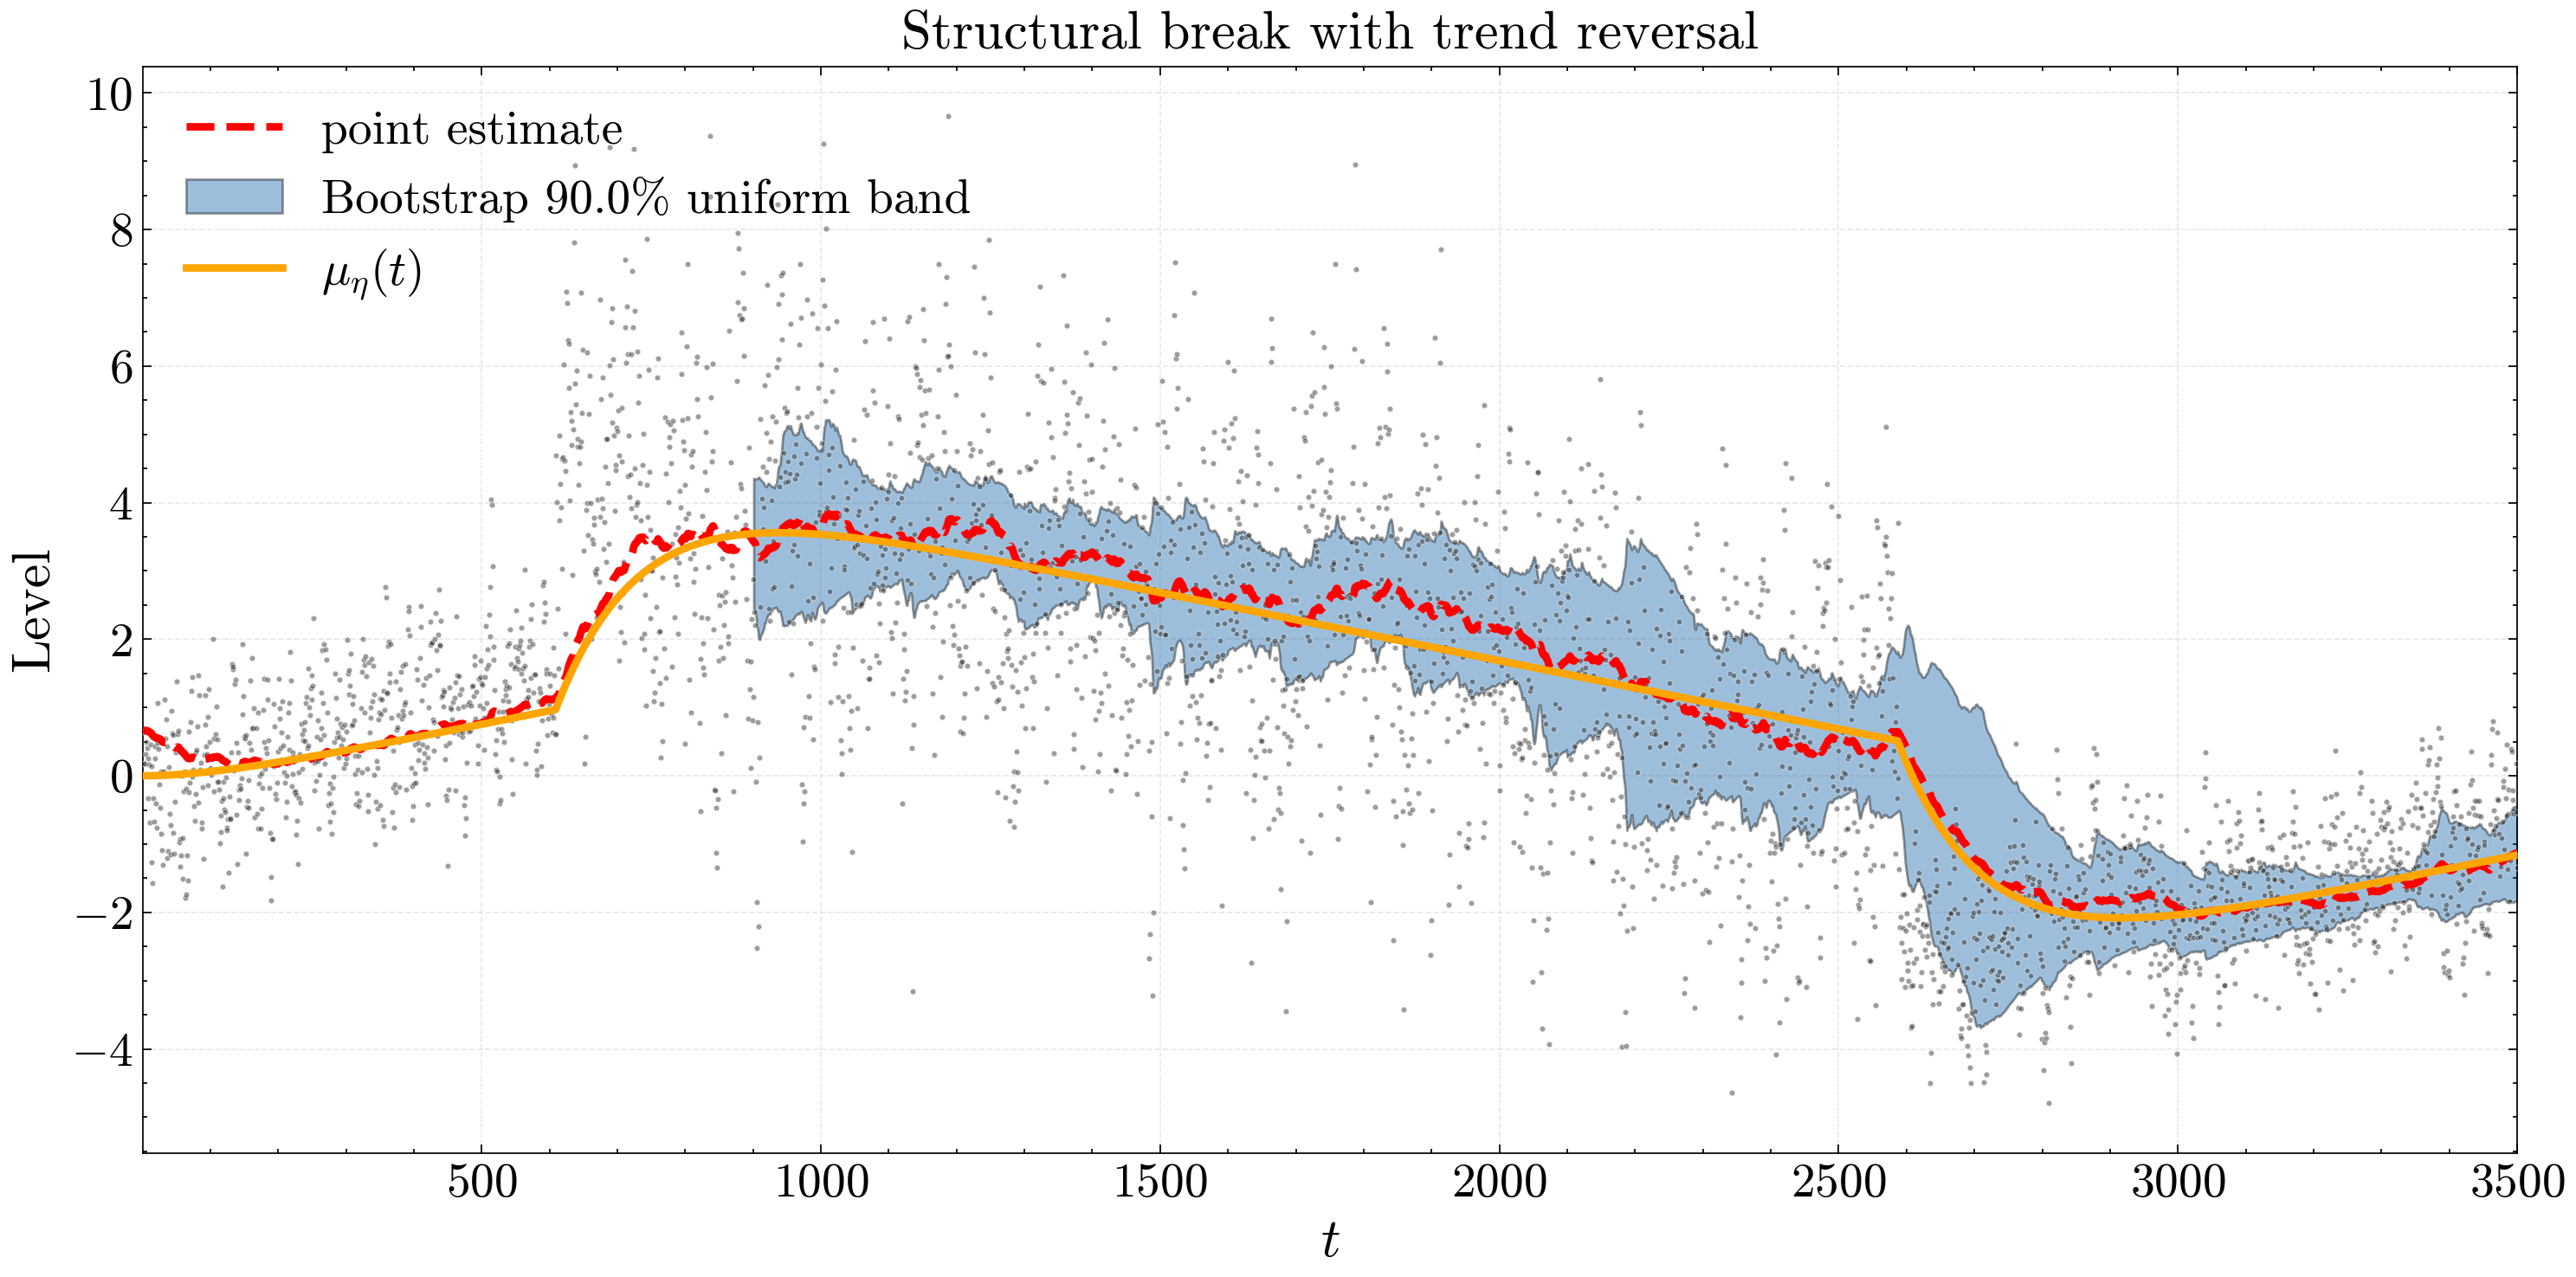

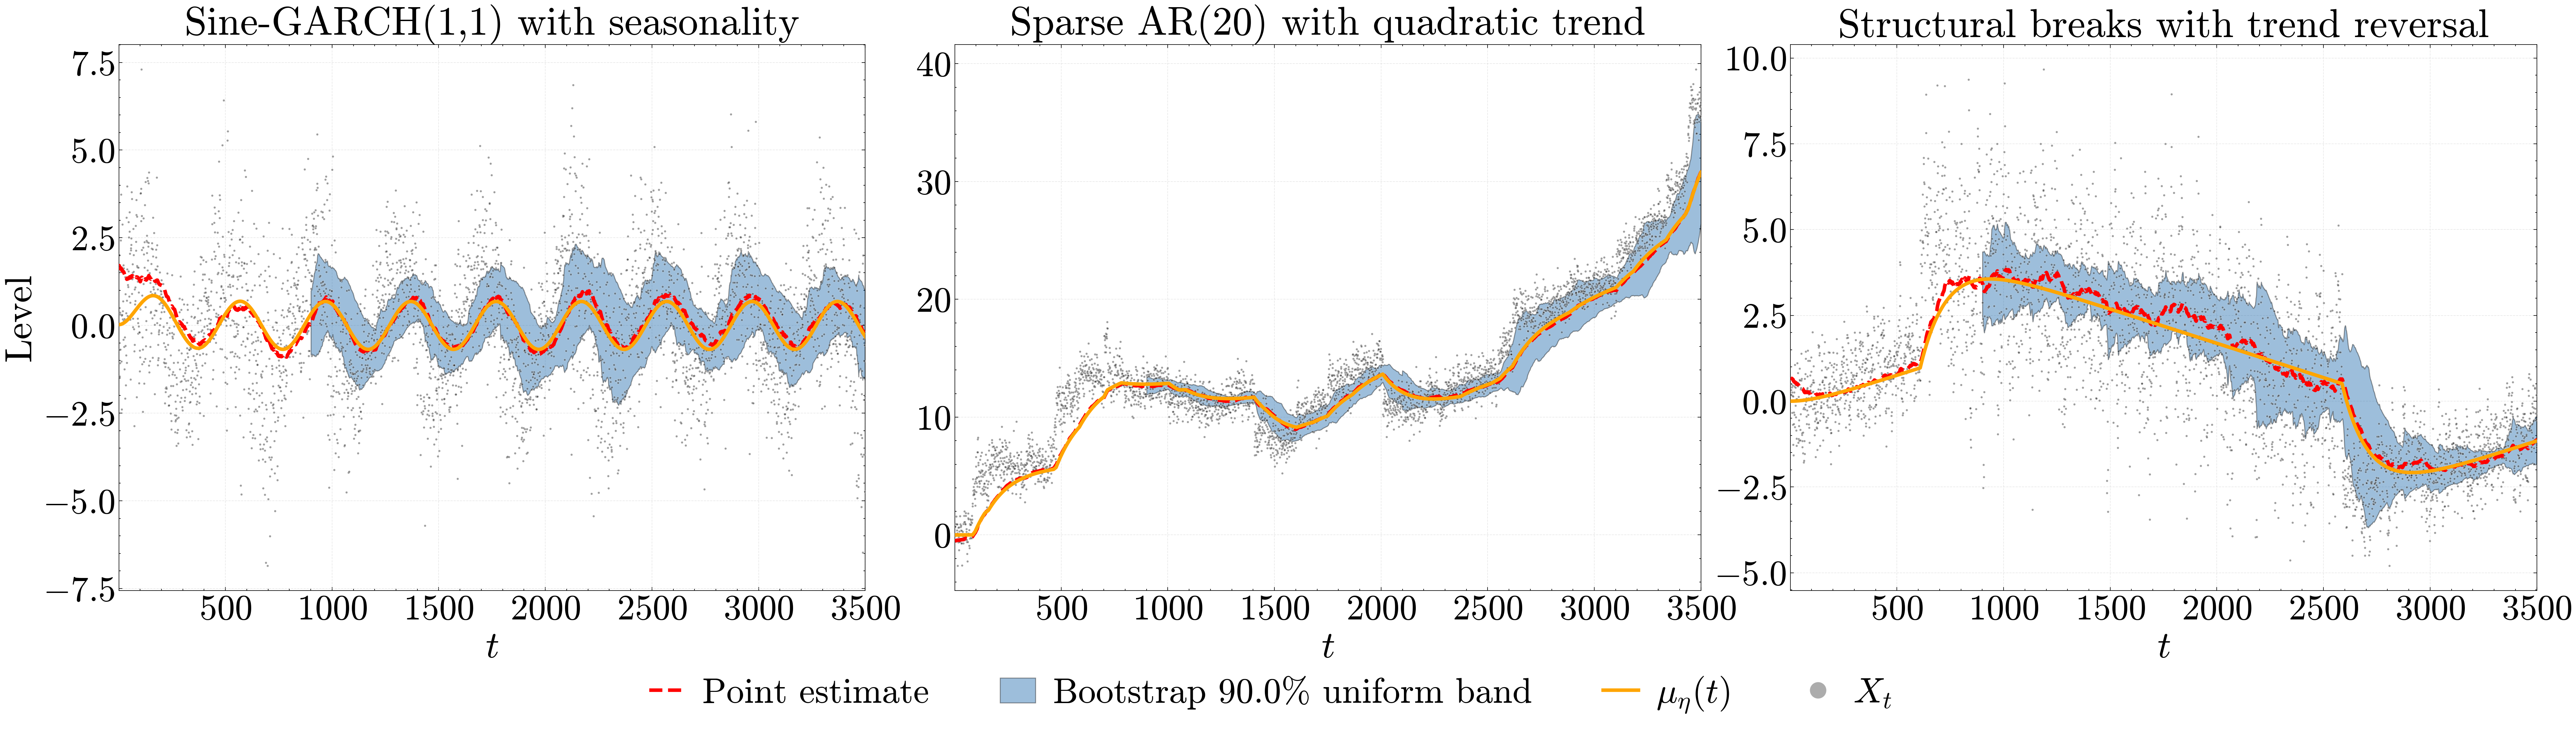

In [ ]:
def make_sparse_ar20(total_mass: float = 0.6) -> np.ndarray:
    """Sparse AR(20) with 5 nonzero coefficients.

    The coefficients sum to `total_mass`, which should stay below 1.
    """
    phi = np.zeros(20, dtype=float)

    # 1-based lags: 1, 2, 5, 10, 20
    nonzero_lags = np.array([0, 1, 4, 9, 19])
    weights = np.array([0.35, 0.25, 0.20, 0.12, 0.08])
    weights = weights / weights.sum()

    phi[nonzero_lags] = total_mass * weights
    return phi


def run_and_plot_process(
    process,
    samples,
    *,
    title: str,
    rng_weights,
    sample_size: int,
    B: int,
    burn_in: int,
    var_warmup: int,
    eta: float,
    alpha: float = 0.1,
):
    exp = OnlineARBootstrapExperiment(
        sample_size=sample_size,
        process=process,
        B=B,
        record_every=1,
        smoothing_method="ewma",
        eta=eta,
        burn_in=burn_in,
        var_warmup=var_warmup,
        smoothing_beta=None,
        gamma=None,
        seasonal_period=None,
        forecast_s=0,
        progress=True,
        rng_weights=rng_weights,
        transform="student",
        transform_power=1.0 / 3.0,
        use_variance_smoothing=False,
        alpha=alpha,
    )

    exp.run(samples=samples)
    exp.compute_intervals(quantile="normal")
    _, _, q_last = exp.compute_uniform_bands()
    cov_both = exp.compute_coverage(band="both")

    if "uniform_covered" in cov_both:
        u_bool = bool(cov_both["uniform_covered"])
        u_mask = cov_both.get("uniform_mask", None)
        u_frac = (
            float(np.mean(u_mask))
            if (u_mask is not None and u_mask.size > 0)
            else float("nan")
        )
        print(
            f"{title} | Uniform covered: {u_bool} "
            f"| fraction covered: {u_frac:.3f} "
            f"| last q_active≈{q_last}"
        )

    res = exp.results()

    plotter = BootstrapPlotter(style="science")
    fig, ax, _ = plotter.plot_bootstrap(
        res,
        plot_series=True,
        alpha=alpha,
        title=title,
        dpi=250,
        show_mu=False,
        show_pointwise_band=False,
        marker_size=1.5,
    )

    return exp, res, fig, ax


master = SeedSequence(123235)
seed_children = master.spawn(6)

rng_garch_data = default_rng(seed_children[0])
rng_garch_weights = default_rng(seed_children[1])

rng_ar20_data = default_rng(seed_children[2])
rng_ar20_weights = default_rng(seed_children[3])

rng_break_data = default_rng(seed_children[4])
rng_break_weights = default_rng(seed_children[5])

mean = 0.0
sample_size = 3500
B = 100
burn_in = 500
var_warmup = 400
eta = 2 / 250
alpha = 0.1

persistence = 0.98
alpha_garch = 0.08
beta_garch = persistence - alpha_garch
target_var = 1.0
omega_garch = (1.0 - persistence) * target_var

garch_proc = GARCH11Process(
    mean=mean,
    omega=omega_garch,
    alpha=alpha_garch,
    beta=beta_garch,
    noise_std=1.0,
    noise_dist="normal",
    trend_slope=0.0,
    seasonal_amplitude=1.5,
    seasonal_period=400,
    seasonal_phase=0.0,
    shock_type="none",
    rng=rng_garch_data,
    nonlinear_sin=True,
    nonlinear_coef=0.8,
)

samples_garch = garch_proc.generate_samples(sample_size)

exp_garch, res_garch, fig_garch, ax_garch = run_and_plot_process(
    garch_proc,
    samples_garch,
    title="Sine-GARCH(1,1)",
    rng_weights=rng_garch_weights,
    sample_size=sample_size,
    B=B,
    burn_in=burn_in,
    var_warmup=var_warmup,
    eta=eta,
    alpha=alpha,
)

phi_ar20 = make_sparse_ar20(total_mass=0.6)

ar20_proc = AR1Process(
    mean=mean,
    phi=phi_ar20,
    noise_std=1.0,
    quadratic_trend=True,
    trend_slope=1e-6,
    seasonal_amplitude=0.0,
    seasonal_period=None,
    seasonal_phase=0.0,
    shock_type="permanent",
    jump_prob=0.01,
    jump_scale=2,
    rng=rng_ar20_data,
)

samples_ar20 = ar20_proc.generate_samples(sample_size)

exp_ar20, res_ar20, fig_ar20, ax_ar20 = run_and_plot_process(
    ar20_proc,
    samples_ar20,
    title="Sparse AR(20)",
    rng_weights=rng_ar20_weights,
    sample_size=sample_size,
    B=B,
    burn_in=burn_in,
    var_warmup=var_warmup,
    eta=eta,
    alpha=alpha,
)


break_proc = AR1Process(
    mean=mean,
    phi=0.6,
    noise_std=1.0,
    trend_slope=0.002,
    shock_type="none",
    structural_break=True,
    n_structural_breaks=2,
    break_margin=500,
    min_break_distance=600,
    structural_break_jump_sizes=[3.0, -3.0],
    positive_trend_noise_scale=0.7,
    negative_trend_noise_scale=1.6,
    rng=rng_break_data,
)

samples_break = break_proc.generate_samples(sample_size)

exp_break, res_break, fig_break, ax_break = run_and_plot_process(
    break_proc,
    samples_break,
    title="Structural break with trend reversal",
    rng_weights=rng_break_weights,
    sample_size=sample_size,
    B=B,
    burn_in=burn_in,
    var_warmup=var_warmup,
    eta=eta,
    alpha=alpha,
)

Path("figs").mkdir(parents=True, exist_ok=True)

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)

fig, axes, _ = plotter.plot_bootstrap_grid(
    [res_garch, res_ar20, res_break],
    titles=[
        "Sine-GARCH(1,1) with seasonality",
        "Sparse AR(20) with quadratic trend",
        "Structural breaks with trend reversal",
    ],
    layout=(1, 3),
    common_legend=True,
    align_axes=False,
    legend_loc="lower center",
    legend_ncol=None,
    legend_bbox=(0.5, -0.06),
    reduce_whitespace=True,
    hspace=0.25,
    wspace=0.12,
    bottom_pad=0.16,
    legend_fontsize=30,
    tick_labelsize=30,
    axis_labelsize=32,
    title_size=34,
    marker_size=1,
    line_width=3,
    plot_series=True,
    show_mu=False,
    show_pointwise_band=False,
    alpha=alpha,
    ylabel="Level",
    save_path="figs/compare_rebuttal_dgps.pdf",
)